<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/7LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import zipfile
import os

# 1. Conectamos a tu Google Drive
drive.mount('/content/gdrive')

# 2. Definimos las rutas
ruta_zip = '/content/gdrive/MyDrive/SIS420IA/fruits-360-100x100-main.zip'
ruta_destino = '/content/dataset_frutas' # Lo extraemos en Colab para que sea rapidísimo y no se pierdan datos

# 3. Descomprimimos
print("Descomprimiendo el dataset original completo... (esto tomará un par de minutos)")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_destino)

print("¡Descomprimido con éxito!")

# 4. Verificamos que la carpeta principal esté ahí
print("Contenido en la carpeta de destino:", os.listdir(ruta_destino))

Mounted at /content/gdrive
Descomprimiendo el dataset original completo... (esto tomará un par de minutos)
¡Descomprimido con éxito!
Contenido en la carpeta de destino: ['fruits-360-100x100-main']


Ordenando las imágenes a velocidad luz en Colab...

✅ ¡Carpetas creadas con éxito! Aquí tienes el resumen exacto:
 📁 Apple: 1000 imágenes
 📁 Banana: 1000 imágenes
 📁 Cherry: 1000 imágenes
 📁 Grape: 1000 imágenes
 📁 Mango: 1000 imágenes
 📁 Orange: 1000 imágenes
 📁 Peach: 1000 imágenes
 📁 Pear: 1000 imágenes
 📁 Pepper: 1000 imágenes
 📁 Plum: 1000 imágenes
 📁 Potato: 1000 imágenes
 📁 Raspberry: 1000 imágenes
 📁 Strawberry: 1000 imágenes
 📁 Tomato: 1000 imágenes
 📁 Watermelon: 475 imágenes


In [6]:
ruta_destino_local = '/content/Dataset_15_Familias'

In [5]:
import zipfile

ruta_zip_prueba = '/content/gdrive/MyDrive/SIS420IA/Mi_Dataset_Ordenado.zip'
print("Empaquetando tu carpeta de prueba para el Drive...")

with zipfile.ZipFile(ruta_zip_prueba, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(ruta_destino_local):
        for file in files:
            ruta_absoluta = os.path.join(root, file)
            # Guardamos con la estructura de carpetas correcta
            ruta_relativa = os.path.relpath(ruta_absoluta, '/content')
            zipf.write(ruta_absoluta, ruta_relativa)

print(f"✅ ¡Tu prueba manual está guardada a salvo en tu Drive como: Mi_Dataset_Ordenado.zip!")

Empaquetando tu carpeta de prueba para el Drive...
✅ ¡Tu prueba manual está guardada a salvo en tu Drive como: Mi_Dataset_Ordenado.zip!


**DESDE AQUI TRABAJO**

1 NORMALIZACION DE IMAGENES

In [7]:
from google.colab import drive
import zipfile
import os
import numpy as np
from PIL import Image

# 1. Conectamos a Drive
drive.mount('/content/gdrive')

# 2. Descomprimimos TU dataset (el que preparaste manualmente)
ruta_zip_preparado = '/content/gdrive/MyDrive/SIS420IA/Mi_Dataset_Ordenado.zip'
ruta_extraccion = '/content' # Al extraerlo aquí, aparecerá la carpeta /content/Dataset_15_Familias

print("1️⃣ Descomprimiendo tu dataset manual...")
with zipfile.ZipFile(ruta_zip_preparado, 'r') as zip_ref:
    zip_ref.extractall(ruta_extraccion)

ruta_carpetas = '/content/Dataset_15_Familias'
carpetas_clases = sorted(os.listdir(ruta_carpetas))
print(f"Familias encontradas ({len(carpetas_clases)}):", carpetas_clases)

# 3. Convertimos las imágenes a matrices matemáticas
print("\n2️⃣ Convirtiendo las imágenes a datos para el modelo...")
X_list = []
y_list = []

# Le asignamos un número a cada familia automáticamente (Apple=0, Banana=1, etc.)
label_to_id = {familia: i for i, familia in enumerate(carpetas_clases)}

for nombre_clase in carpetas_clases:
    ruta_clase = os.path.join(ruta_carpetas, nombre_clase)
    if not os.path.isdir(ruta_clase): continue

    for archivo in os.listdir(ruta_clase):
        if archivo.endswith(('.jpg', '.jpeg', '.png')):
            ruta_img = os.path.join(ruta_clase, archivo)

            # Aplanamos (30,000 dimensiones) y normalizamos (0 a 1)
            img = Image.open(ruta_img).convert('RGB')
            img_vector = np.array(img).flatten() / 255.0

            X_list.append(img_vector)
            y_list.append(label_to_id[nombre_clase])

# Convertimos a formato NumPy
X_full = np.array(X_list, dtype=np.float32)
y_full = np.array(y_list, dtype=np.int64)

# 4. Guardamos tu archivo .npz oficial
ruta_npz = '/content/gdrive/MyDrive/SIS420IA/dataset_frutas_procesado.npz'
np.savez_compressed(ruta_npz, X=X_full, y=y_full)

print(f"\n✅ ¡Listo! Dataset guardado exitosamente en: {ruta_npz}")
print(f"📊 Forma de X (Datos): {X_full.shape}")
print(f"📊 Forma de y (Etiquetas): {y_full.shape}")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
1️⃣ Descomprimiendo tu dataset manual...
Familias encontradas (15): ['Apple', 'Banana', 'Cherry', 'Grape', 'Mango', 'Orange', 'Peach', 'Pear', 'Pepper', 'Plum', 'Potato', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']

2️⃣ Convirtiendo las imágenes a datos para el modelo...

✅ ¡Listo! Dataset guardado exitosamente en: /content/gdrive/MyDrive/SIS420IA/dataset_frutas_procesado.npz
📊 Forma de X (Datos): (14475, 30000)
📊 Forma de y (Etiquetas): (14475,)


**SEMISUPERVISADO**

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Cargamos TU archivo procesado (no el de bloodmnist)
data = np.load("/content/gdrive/MyDrive/SIS420IA/dataset_frutas_procesado.npz")

X_full = data["X"]
y_full = data["y"]

# 2. Dividimos los datos directamente (80% para entrenar, 20% para testear)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11580, 30000)
y_train shape: (11580,)
X_test shape: (2895, 30000)
y_test shape: (2895,)


DEFINICION DE K //PUEDO MODIFICAR SI LO NECESITO

In [11]:
from sklearn.cluster import KMeans
k = 50
print(f"Buscando {k} frutas representativas...")
kmeans = KMeans(n_clusters=k, random_state=42)
X_fruits_dist = kmeans.fit_transform(X_train)

print("Distancias calculadas. Forma:", X_fruits_dist.shape)

Buscando 50 frutas representativas...
Distancias calculadas. Forma: (11580, 50)


In [12]:
idxs = np.argmin(X_fruits_dist, axis=0)
X_representative_fruits = X_train[idxs]

Mostrando las 50 frutas más representativas:


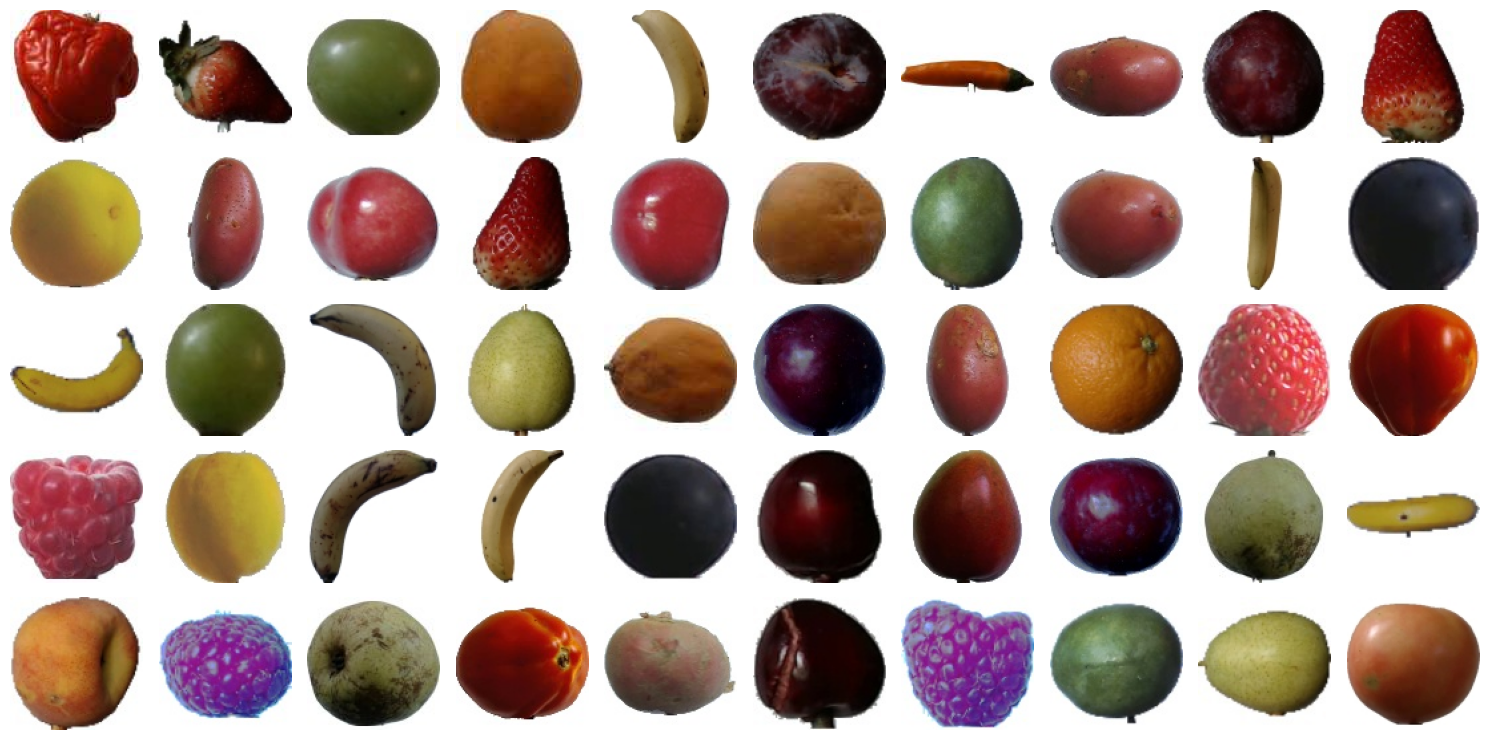

In [13]:
import matplotlib.pyplot as plt
import math

# Lógica dinámica: calcula la cuadrícula perfecta según el valor de 'k' que elijas
columnas = 10 if k >= 20 else 5
filas = math.ceil(k / columnas)

print(f"Mostrando las {k} frutas más representativas:")
plt.figure(figsize=(columnas * 1.5, filas * 1.5))

for index, X_representative_fruit in enumerate(X_representative_fruits):
    plt.subplot(filas, columnas, index + 1)
    # Adaptado a 100x100
    plt.imshow(X_representative_fruit.reshape(100, 100, 3))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
y_representative_fruits = y_train[idxs]

In [15]:
from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_fruits, y_representative_fruits)
print(f"Precisión con las {k} frutas representativas:", log_reg2.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 13.7 s, sys: 14.6 ms, total: 13.7 s
Wall time: 8.48 s
Precisión con las 50 frutas representativas: 0.6500863557858376


In [16]:
idxs_azar = np.random.choice(len(X_train), k, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

%time log_reg.fit(X_train[idxs_azar], y_train[idxs_azar])
print(f"Precisión con {k} frutas al azar:", log_reg.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 12.6 s, sys: 24.2 ms, total: 12.7 s
Wall time: 7.4 s
Precisión con 50 frutas al azar: 0.5043177892918825


In [17]:
# 1. Propagamos
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_fruits[i]

# 2. Entrenamos
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
print(f"Precisión final con Propagación de Etiquetas (k={k}):", log_reg3.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 28s, sys: 175 ms, total: 1min 28s
Wall time: 53 s
Precisión final con Propagación de Etiquetas (k=50): 0.6576856649395509


**ACTIVO**

In [18]:
probas = log_reg3.predict_proba(X_train[:1000])

labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)

# Mostramos el nivel de confianza de las 10 peores (las que más lo confunden)
labels[sorted_ixs[:10]]

array([0.88568236, 0.90360163, 0.91816226, 0.91823667, 0.92370925,
       0.92663214, 0.93022262, 0.93198988, 0.93343114, 0.93580249])

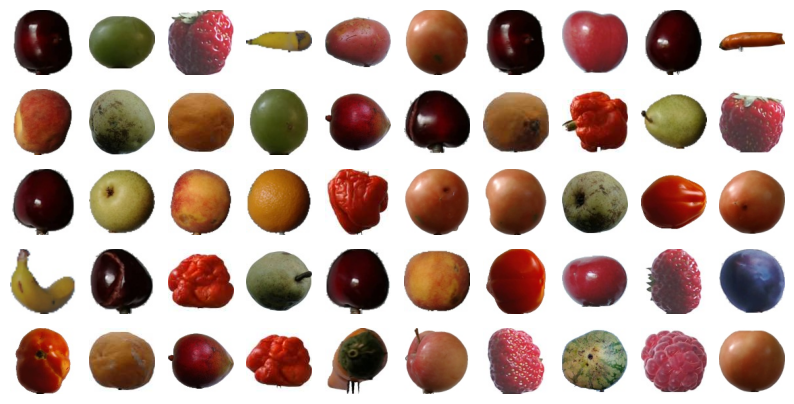

In [19]:
import matplotlib.pyplot as plt

k = 50 # Definimos k (por ejemplo, 50 imágenes a revisar)
X_lowest = X_train[:1000][sorted_ixs[:k]]

plt.figure(figsize=(10, 5))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)

    plt.imshow(img.reshape(100, 100, 3))
    plt.axis('off')
plt.show()

In [20]:

y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([ 2,  3, 12,  1, 10, 13,  2,  2,  2,  8,  6,  7,  5,  3,  4,  2,  5,
        8,  7, 12,  2,  7,  6,  5,  8, 13, 13,  7, 13, 13,  1,  2,  8,  7,
        2,  6, 13,  2, 12,  9, 13,  5,  4,  8,  8,  0, 12, 14, 11, 13])

In [21]:

y_train2 = y_train_propagated[:1000].copy()


y_train2[sorted_ixs[:k]] = y_lowest

In [22]:
from sklearn.linear_model import LogisticRegression


log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)


%time log_reg5.fit(X_train[:1000], y_train2)

score = log_reg5.score(X_test, y_test)
print(f"Precisión final tras aprendizaje activo: {score * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 47s, sys: 260 ms, total: 1min 47s
Wall time: 1min 4s
Precisión final tras aprendizaje activo: 68.12%
